In [47]:
import numpy as np
import matplotlib.pyplot as plt

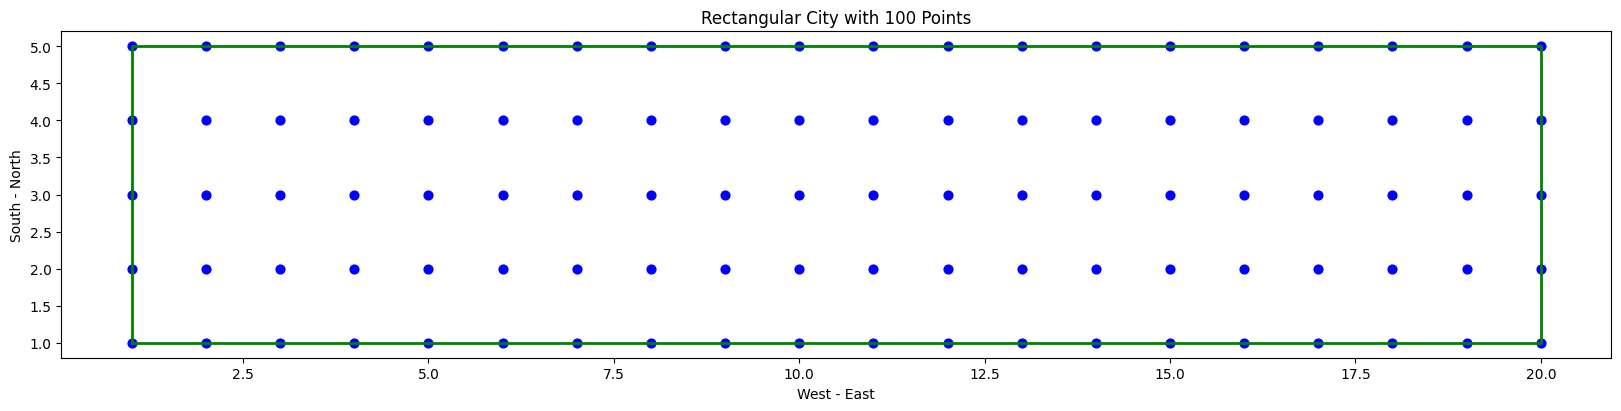

In [48]:
# Rectangular City
n_x = 20  # points along the x-axis
n_y = 5  # points along the y-axis
n_points = n_x * n_y  # total points (100)

# Create evenly spaced x and y coordinates
x = np.linspace(1, n_x, n_x)
y = np.linspace(1, n_y, n_y)

# Generate grid points (Cartesian product)
xx, yy = np.meshgrid(x, y)
points_rect = np.column_stack([xx.ravel(), yy.ravel()])

points = points_rect

# Plot
plt.figure(figsize=(n_x,n_y))
plt.scatter(points[:,0], points[:,1], color='blue', s=40)
plt.title(f"Rectangular City with {n_points} Points")
plt.xlabel("West - East")
plt.ylabel("South - North")
plt.gca().set_aspect('equal', adjustable='box')
rect_x = [1, 20, 20, 1, 1]
rect_y = [1, 1, 5, 5, 1]
plt.plot(rect_x, rect_y, color='green', linewidth=2)
plt.show()


Triangular city points (20°): 100
Triangular city points (60°): 100
Triangular city points (110°): 100


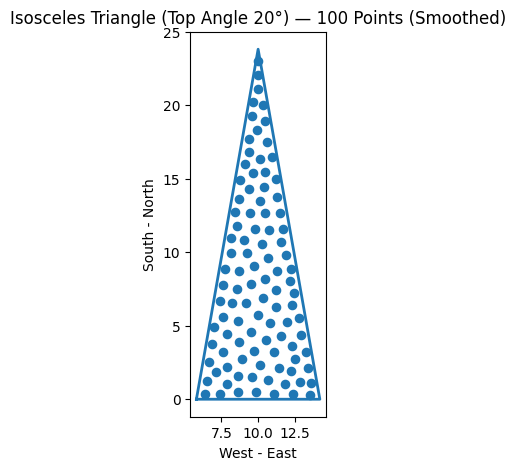

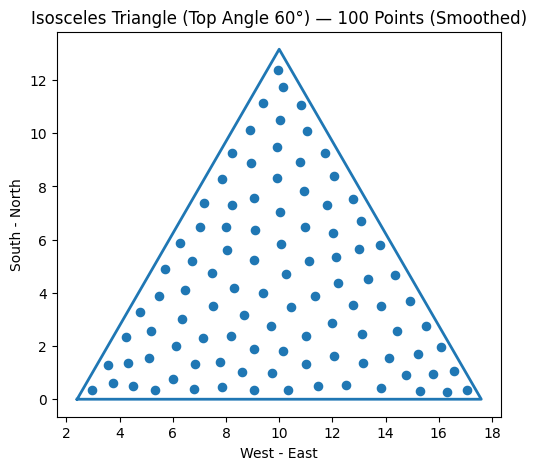

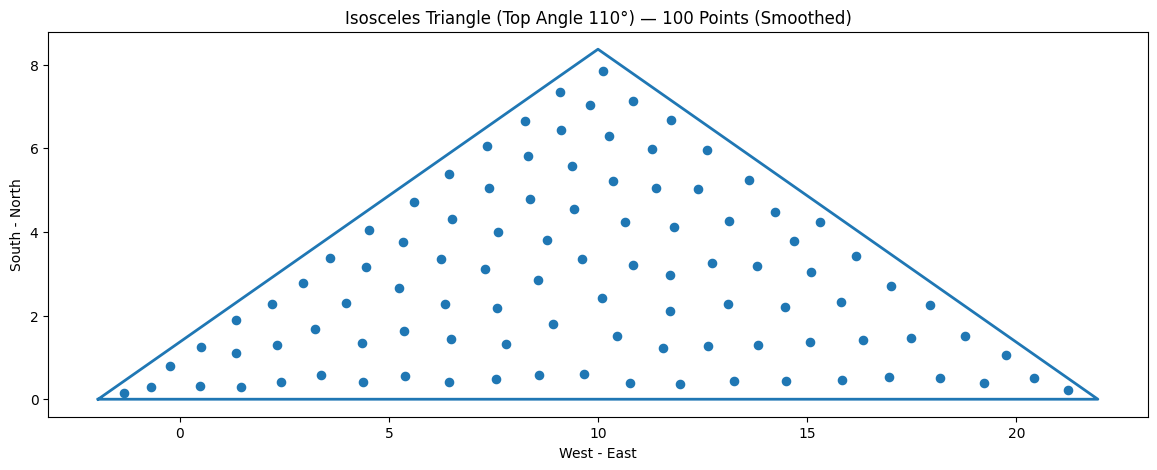

Y coordinate for equal split: 2.306372894194526


In [49]:
N = 100
rng = np.random.default_rng(0)

x_mid = 10.0
y_base = 0.0
A0 = 100.0  # constant area across triangles

def triangle_from_apex_angle(theta_deg, x_mid=10.0, y_base=0.0, area=100.0):
    theta = np.deg2rad(theta_deg)
    h = np.sqrt(area / np.tan(theta / 2))
    base = 2 * h * np.tan(theta / 2)
    A = np.array([x_mid - base/2, y_base])
    B = np.array([x_mid + base/2, y_base])
    C = np.array([x_mid, y_base + h])
    return A, B, C

def barycentric(P, A, B, C):
    v0 = B - A
    v1 = C - A
    v2 = P - A
    d00 = np.dot(v0, v0)
    d01 = np.dot(v0, v1)
    d11 = np.dot(v1, v1)
    d20 = np.dot(v2, v0)
    d21 = np.dot(v2, v1)
    denom = d00 * d11 - d01 * d01
    if abs(denom) < 1e-15:
        return np.array([-1.0, -1.0, -1.0])
    v = (d11 * d20 - d01 * d21) / denom
    w = (d00 * d21 - d01 * d20) / denom
    u = 1.0 - v - w
    return np.array([u, v, w])

def inside_triangle(P, A, B, C, eps=1e-12):
    bc = barycentric(P, A, B, C)
    return np.all(bc >= -eps)

def project_to_triangle(P, A, B, C):
    bc = barycentric(P, A, B, C)
    bc = np.maximum(bc, 0.0)
    s = bc.sum()
    if s <= 1e-15:
        bc = np.array([1/3, 1/3, 1/3])
    else:
        bc = bc / s
    return bc[0]*A + bc[1]*B + bc[2]*C

# Uniform random points in triangle (area-uniform)
def uniform_points_in_triangle(A, B, C, M, rng):
    u = rng.random(M)
    v = rng.random(M)
    swap = (u + v) > 1.0
    u[swap] = 1.0 - u[swap]
    v[swap] = 1.0 - v[swap]
    return A + u[:, None] * (B - A) + v[:, None] * (C - A)

#  Blue-noise style
def farthest_point_sample(pool, N, rng):
    M = pool.shape[0]
    start = rng.integers(M)
    chosen = np.empty(N, dtype=int)
    chosen[0] = start
    d2 = np.sum((pool - pool[start])**2, axis=1)

    for k in range(1, N):
        i = np.argmax(d2)
        chosen[k] = i
        d2 = np.minimum(d2, np.sum((pool - pool[i])**2, axis=1))

    return pool[chosen]

# Lloyd smoothing
def lloyd_smooth(points, A, B, C, rng, iters=6, samples_per_iter=6000):
    P = points.copy()

    for _ in range(iters):
        S = uniform_points_in_triangle(A, B, C, samples_per_iter, rng)

        d2 = np.sum((S[:, None, :] - P[None, :, :])**2, axis=2)
        owner = np.argmin(d2, axis=1)

        # move each generator to centroid of its owned samples
        newP = P.copy()
        for i in range(P.shape[0]):
            mask = (owner == i)
            if np.any(mask):
                newP[i] = S[mask].mean(axis=0)

        # keep inside triangle
        for i in range(newP.shape[0]):
            if not inside_triangle(newP[i], A, B, C):
                newP[i] = project_to_triangle(newP[i], A, B, C)

        P = newP

    return P

def make_very_even_triangle_points(A, B, C, N, rng,
                                   pool_multiplier=400,
                                   lloyd_iters=6,
                                   lloyd_samples=8000):
    pool = uniform_points_in_triangle(A, B, C, pool_multiplier * N, rng)
    pts = farthest_point_sample(pool, N, rng)
    pts = lloyd_smooth(pts, A, B, C, rng, iters=lloyd_iters, samples_per_iter=lloyd_samples)
    return pts

# Generate 20°, 60°, 110°
A20, B20, C20 = triangle_from_apex_angle(20, x_mid, y_base, A0)
points_tri20 = make_very_even_triangle_points(A20, B20, C20, N, rng)

A60, B60, C60 = triangle_from_apex_angle(60, x_mid, y_base, A0)
points_tri60 = make_very_even_triangle_points(A60, B60, C60, N, rng)

A110, B110, C110 = triangle_from_apex_angle(110, x_mid, y_base, A0)
points_tri110 = make_very_even_triangle_points(A110, B110, C110, N, rng)

print("Triangular city points (20°):", len(points_tri20))
print("Triangular city points (60°):", len(points_tri60))
print("Triangular city points (110°):", len(points_tri110))

# Plot helper
def plot_triangle(points, A, B, C, title):
    plt.figure(figsize=(n_x, n_y))
    plt.scatter(points[:, 0], points[:, 1], s=35)
    plt.title(title)
    plt.xlabel("West - East")
    plt.ylabel("South - North")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.plot([A[0], B[0], C[0], A[0]],
             [A[1], B[1], C[1], A[1]], linewidth=2)
    plt.show()

plot_triangle(points_tri20, A20, B20, C20, "Isosceles Triangle (Top Angle 20°) — 100 Points (Smoothed)")
plot_triangle(points_tri60, A60, B60, C60, "Isosceles Triangle (Top Angle 60°) — 100 Points (Smoothed)")
plot_triangle(points_tri110, A110, B110, C110, "Isosceles Triangle (Top Angle 110°) — 100 Points (Smoothed)")

y_line = np.median(points_tri110[:, 1])
print("Y coordinate for equal split:", y_line)

Circular city points: 100


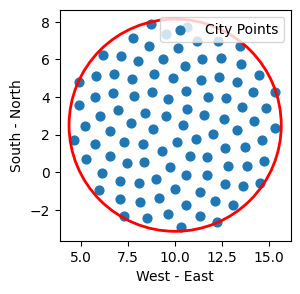

In [50]:
# Circular city
cx, cy = 10.0, 2.5
R = np.sqrt(100/np.pi)
N = 100

# Fibonacci disk
golden_angle = np.pi * (3 - np.sqrt(5))

i = np.arange(N)

# radius chosen for uniform area fill
r = R * np.sqrt((i + 0.5) / N)
theta = i * golden_angle

x = cx + r * np.cos(theta)
y = cy + r * np.sin(theta)

points_circ = np.column_stack([x, y])

print("Circular city points:", len(points_circ))

# Plot
plt.figure(figsize=(10, 3))
plt.scatter(points_circ[:, 0], points_circ[:, 1], s=40, label="City Points")

circle = plt.Circle((cx, cy), R, fill=False, color="red", lw=2)
plt.gca().add_patch(circle)

plt.xlabel("West - East")
plt.ylabel("South - North")

margin = 0.5
plt.xlim(cx - R - margin, cx + R + margin)
plt.ylim(cy - R - margin, cy + R + margin)
plt.gca().set_aspect("equal", adjustable="box")

plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.show()

In [51]:
points = points_rect   # rectangular
# points = points_tri20
# points = points_tri60
# points = points_tri110   # triangular
# points = points_circ   # circular

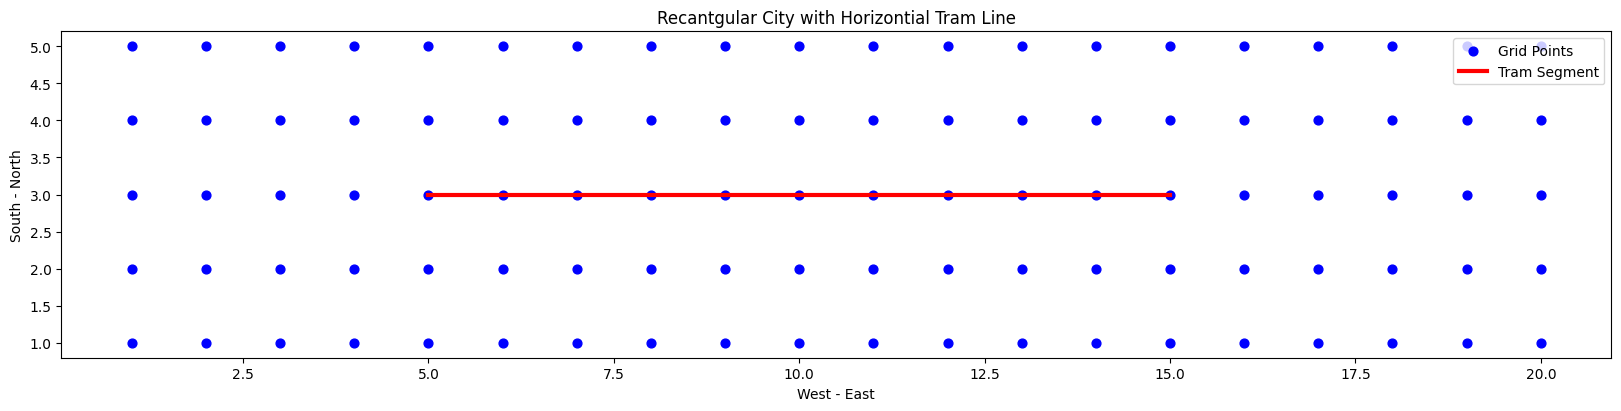

In [52]:
# Tram segment endpoints
y_mid = np.median(points[:,1])
x1, x2 = 5,15
y1 = y2 = y_mid
p1 = np.array([x1, y1])
p2 = np.array([x2, y2])

# Plot
plt.figure(figsize=(n_x,n_y))
plt.scatter(points[:,0], points[:,1], color='blue', s=40, label='Grid Points')
plt.plot([x1, x2], [y1, y2], color = 'red', lw=3, label='Tram Segment')
plt.title("Recantgular City with Horizontial Tram Line")
plt.xlabel("West - East")
plt.ylabel("South - North")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


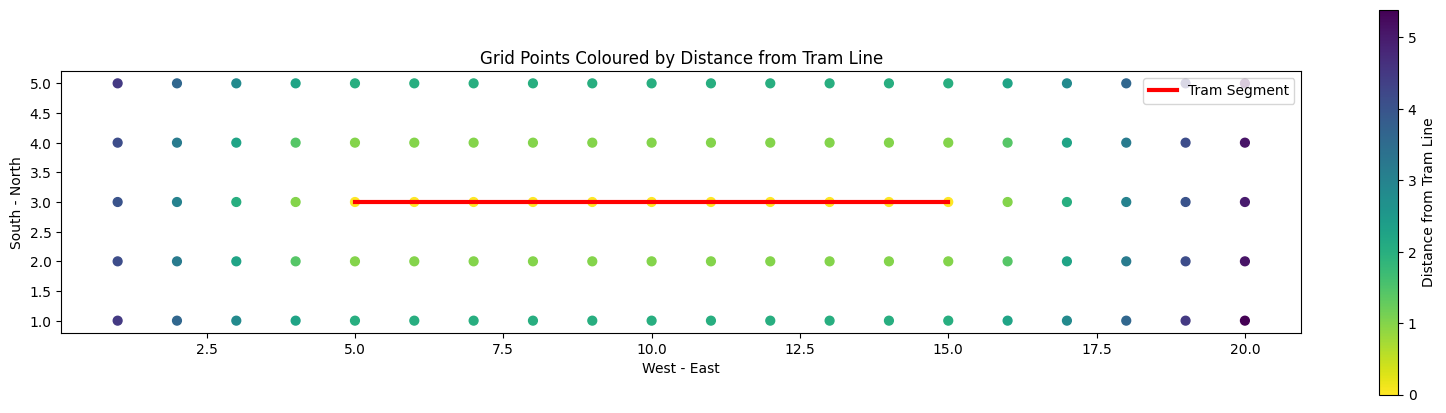

In [53]:
def distances_to_segment(points, x1, y1, x2, y2):

    A = np.array([x1, y1], dtype=float)
    B = np.array([x2, y2], dtype=float)
    AB = B - A
    AB2 = AB.dot(AB)

    # Degenerate segment (A == B)
    if AB2 == 0.0:
        return np.linalg.norm(points - A, axis=1)

    AP = points - A
    # Scalar projection parameter t for each point onto AB
    t = (AP @ AB) / AB2
    # Clamp to the segment [0,1]
    t_clamped = np.clip(t, 0.0, 1.0)

    # Closest points on the segment to each input point
    closest = A + t_clamped[:, None] * AB
    # Euclidean distances
    return np.linalg.norm(points - closest, axis=1)

# x1, y1, x2, y2: endpoints of the tram segment
distances = distances_to_segment(points, x1, y1, x2, y2)

plt.figure(figsize=(n_x, n_y))
sc = plt.scatter(points[:, 0], points[:, 1], c=distances, cmap='viridis_r', s=40)
plt.plot([x1, x2], [y1, y2], color='red', lw=3, label='Tram Segment')
plt.colorbar(sc, label='Distance from Tram Line')
plt.title("Grid Points Coloured by Distance from Tram Line")
plt.xlabel("West - East")
plt.ylabel("South - North")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

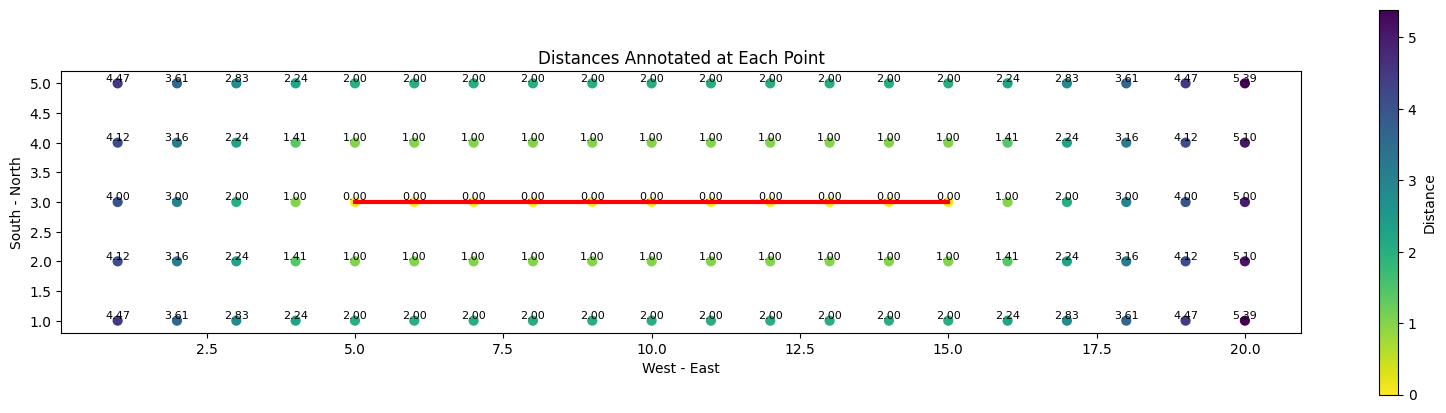

In [54]:
plt.figure(figsize=(n_x, n_y))
sc = plt.scatter(points[:,0], points[:,1], c=distances, cmap='viridis_r', s=40)
plt.plot([x1, x2], [y1, y2], color = 'red', lw=3, label='Tram Segment')

# Distances to the tram annotated at each point
for (px, py), d in zip(points, distances):
    plt.text(px, py, f"{d:.2f}", fontsize=8, ha='center', va='bottom')

#Plot
plt.colorbar(label='Distance')
plt.title("Distances Annotated at Each Point")
plt.xlabel("West - East"); plt.ylabel("South - North")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


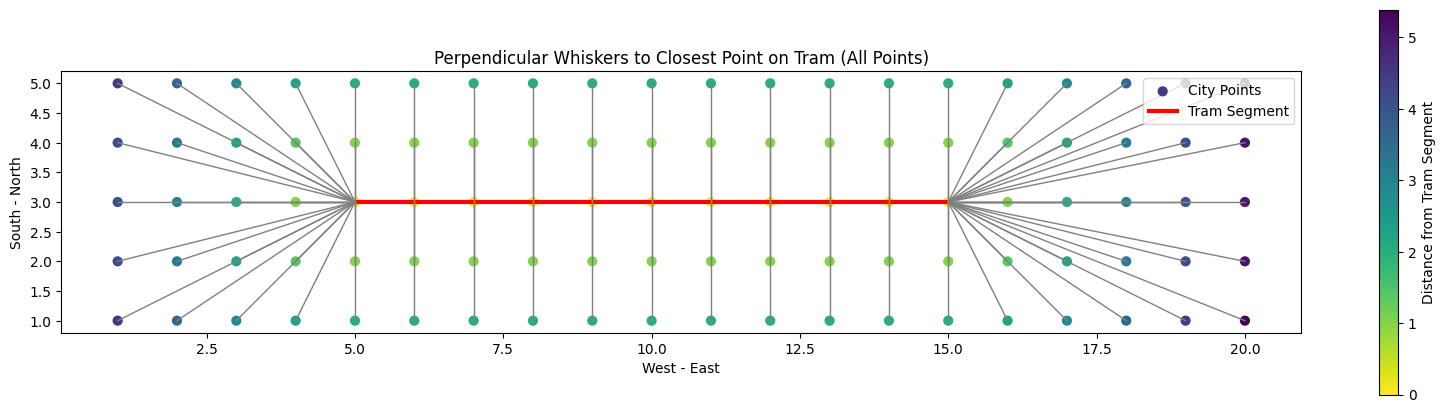

In [55]:
# Plot
plt.figure(figsize=(n_x, n_y))

sc = plt.scatter(points[:, 0], points[:, 1], c=distances, cmap='viridis_r', s=40, label="City Points")
plt.plot([x1, x2], [y1, y2], color='red', lw=3, label='Tram Segment')

# Whiskers (ALL points)
for i in range(len(points)):
    plt.plot([points[i, 0], closest[i, 0]],
             [points[i, 1], closest[i, 1]],
             color='gray', lw=1)

plt.colorbar(sc, label='Distance from Tram Segment')
plt.title("Perpendicular Whiskers to Closest Point on Tram (All Points)")
plt.xlabel("West - East")
plt.ylabel("South - North")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()



In [56]:
N = len(points)
walking_distances = np.zeros((N, N))

for i in range(N):
    xi, yi = points[i]
    for j in range(N):
        xj, yj = points[j]
        walking_distances[i, j] = np.hypot(xi - xj, yi - yj)

print("Matrix shape:", walking_distances.shape)   # (100, 100)
print("Total calculations:", walking_distances.size)  # 10000
print("Top-left 3x3 block:\n", walking_distances[:3, :3])

Matrix shape: (100, 100)
Total calculations: 10000
Top-left 3x3 block:
 [[0. 1. 2.]
 [1. 0. 1.]
 [2. 1. 0.]]


In [57]:
N = len(points)
walking_distances = np.zeros((N, N))

for i in range(N):
    xi, yi = points[i]
    for j in range(N):
        xj, yj = points[j]
        walking_distances[i, j] = np.hypot(xi - xj, yi - yj)

In [58]:
N = len(points)
distances_tram = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        distances_tram[i, j] = distances[i] + distances[j]

print("Matrix shape:", distances_tram.shape)  # (100, 100)
print("Total values:", distances_tram.size)   # 10000
print("Top-left 3×3 block:\n", distances_tram[:3, :3])

Matrix shape: (100, 100)
Total values: 10000
Top-left 3×3 block:
 [[8.94427191 8.07768723 7.30056308]
 [8.07768723 7.21110255 6.4339784 ]
 [7.30056308 6.4339784  5.65685425]]


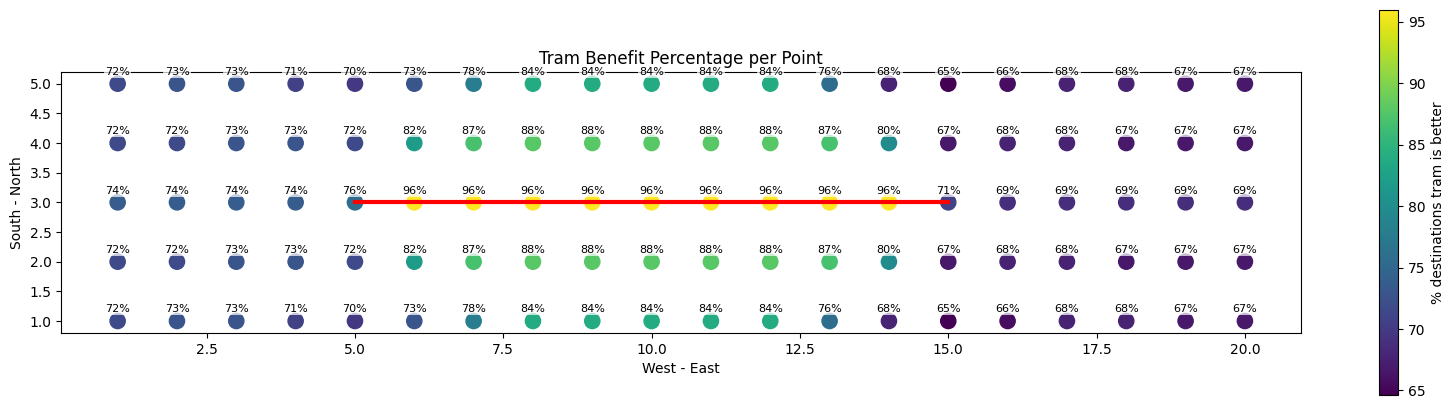

Overall tram benefit percentage: 76.63%


In [59]:
# Elementwise comparison for each origin (row) vs all destinations (cols)
tram_better_matrix = distances_tram < walking_distances

# Ignore self-comparisons (i -> i)
np.fill_diagonal(tram_better_matrix, False)

# Count where tram is better for each origin
tram_better_counts = tram_better_matrix.sum(axis=1)  # shape (100,)

# Convert to percentage (out of 99 possible destinations)
tram_better_pct = 100 * tram_better_counts / (N - 1)

plt.figure(figsize=(n_x, n_y))
plt.scatter(points[:, 0], points[:, 1], c=tram_better_pct, cmap='viridis', s=120)
plt.plot([x1, x2], [y1, y2], color='red', lw=3)  # tram line
plt.colorbar(label="% destinations tram is better")
plt.title("Tram Benefit Percentage per Point")
plt.xlabel("West - East")
plt.ylabel("South - North")
plt.gca().set_aspect('equal', adjustable='box')

for (px, py), pct in zip(points, tram_better_pct):
    plt.text(px, py + 0.15,
             f"{pct:.0f}%",
             fontsize=8,
             ha='center',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
plt.show()

overall_tram_benefit = np.mean(tram_better_pct)
print(f"Overall tram benefit percentage: {overall_tram_benefit:.2f}%")


In [60]:
# Pick a random point to inspect
k = 0  # change this to any point index 0..N-1

print(f"\n=== Detailed comparison for origin point {k} ===")

# Extract rows
direct_row  = walking_distances[k]        # direct distances
tram_row    = distances_tram[k]           # via-tram distances
compare_row = tram_better_matrix[k]       # True/False

# Count how many destinations prefer the tram (excluding itself)
count_for_k = compare_row.sum()
pct_for_k   = tram_better_pct[k]

print(f"Tram is better for {count_for_k} out of {N-1} destinations.")
print(f"Percentage for point {k}: {pct_for_k:.2f}%\n")

# Print table of all distance comparisons
for j in range(N):
    if j == k:
        continue
    print(
        f"To point {j:2d}: "
        f"direct={direct_row[j]:6.2f}, "
        f"via_tram={tram_row[j]:6.2f}, "
        f"tram_better={compare_row[j]}"
    )


=== Detailed comparison for origin point 0 ===
Tram is better for 71 out of 99 destinations.
Percentage for point 0: 71.72%

To point  1: direct=  1.00, via_tram=  8.08, tram_better=False
To point  2: direct=  2.00, via_tram=  7.30, tram_better=False
To point  3: direct=  3.00, via_tram=  6.71, tram_better=False
To point  4: direct=  4.00, via_tram=  6.47, tram_better=False
To point  5: direct=  5.00, via_tram=  6.47, tram_better=False
To point  6: direct=  6.00, via_tram=  6.47, tram_better=False
To point  7: direct=  7.00, via_tram=  6.47, tram_better=True
To point  8: direct=  8.00, via_tram=  6.47, tram_better=True
To point  9: direct=  9.00, via_tram=  6.47, tram_better=True
To point 10: direct= 10.00, via_tram=  6.47, tram_better=True
To point 11: direct= 11.00, via_tram=  6.47, tram_better=True
To point 12: direct= 12.00, via_tram=  6.47, tram_better=True
To point 13: direct= 13.00, via_tram=  6.47, tram_better=True
To point 14: direct= 14.00, via_tram=  6.47, tram_better=True


In [61]:
def projection_t_params(points, x1, y1, x2, y2):
    """
    For each point, compute the clamped projection parameter t in [0,1]
    along the segment A(x1,y1)->B(x2,y2), and return the segment length.
    """
    A = np.array([x1, y1], dtype=float)
    B = np.array([x2, y2], dtype=float)
    AB = B - A
    AB2 = AB.dot(AB)

    if AB2 == 0.0:  # degenerate segment
        t = np.zeros(points.shape[0], dtype=float)
        seg_len = 0.0
        return t, seg_len

    AP = points - A              # (N,2)
    t = (AP @ AB) / AB2          # (N,)
    t = np.clip(t, 0.0, 1.0)     # clamp to [0,1]
    seg_len = np.sqrt(AB2)
    return t, seg_len

t, seg_len = projection_t_params(points, x1, y1, x2, y2)

In [62]:
walking_speed = 5.0

# Tram speed as a multiple of walking speed
tram_speed_factors = [1.0, 2.0, 3.0, 4.0,5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]

overall_usage = []
N = len(points)

for factor in tram_speed_factors:
    tram_speed = factor * walking_speed

    # Walking time
    time_walk = walking_distances / walking_speed

    # Tram time for this factor
    time_tram = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            walk_to_tram_time   = distances[i] / walking_speed
            walk_from_tram_time = distances[j] / walking_speed

            on_tram_distance = seg_len * abs(t[i] - t[j])
            on_tram_time     = on_tram_distance / tram_speed

            time_tram[i, j] = walk_to_tram_time + on_tram_time + walk_from_tram_time

    # Compare times
    tram_better_matrix = time_tram < time_walk
    np.fill_diagonal(tram_better_matrix, False)

    tram_better_counts = tram_better_matrix.sum(axis=1)
    tram_better_pct = 100 * tram_better_counts / (N - 1)
    overall_pct = np.mean(tram_better_pct)

    overall_usage.append(overall_pct)

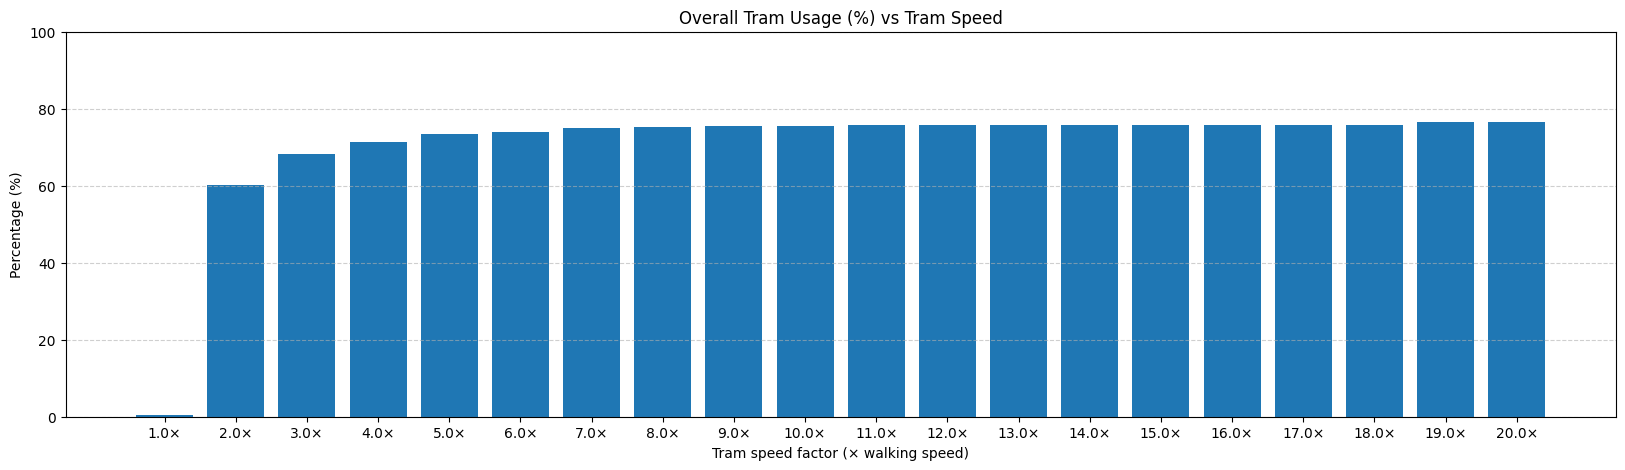

In [63]:
plt.figure(figsize=(n_x, n_y))

labels = [f"{f:.1f}×" for f in tram_speed_factors]
plt.bar(labels, overall_usage)

plt.title("Overall Tram Usage (%) vs Tram Speed")
plt.xlabel("Tram speed factor (× walking speed)")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [64]:
# waiting times in minutes
waiting_times_min = [0, 5, 10, 15]

# convert to hours (to match distance/speed units)
waiting_times = [w / 60.0 for w in waiting_times_min]

N = len(points)

results = {}

for wait, wait_min in zip(waiting_times, waiting_times_min):
    overall_usage = []

    for factor in tram_speed_factors:
        tram_speed = factor * walking_speed

        # Walking time
        time_walk = walking_distances / walking_speed   # shape (N, N)

        # Tram time for this factor + wait time
        time_tram = np.zeros((N, N))

        for i in range(N):
            for j in range(N):
                walk_to_tram_time   = distances[i] / walking_speed
                walk_from_tram_time = distances[j] / walking_speed

                on_tram_distance = seg_len * abs(t[i] - t[j])
                on_tram_time     = on_tram_distance / tram_speed

                # add waiting time once per trip
                total_tram_time = walk_to_tram_time + wait + on_tram_time + walk_from_tram_time

                time_tram[i, j] = total_tram_time

        # Compare times
        tram_better_matrix = time_tram < time_walk
        np.fill_diagonal(tram_better_matrix, False)

        tram_better_counts = tram_better_matrix.sum(axis=1)
        tram_better_pct = 100 * tram_better_counts / (N - 1)
        overall_pct = np.mean(tram_better_pct)

        overall_usage.append(overall_pct)

    results[wait_min] = overall_usage

print("Tram speed factors:", tram_speed_factors)
for wait_min in waiting_times_min:
    print(f"Wait {wait_min} min -> usage %:", results[wait_min])

Tram speed factors: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]
Wait 0 min -> usage %: [np.float64(0.5454545454545454), np.float64(60.30303030303031), np.float64(68.14141414141415), np.float64(71.25252525252525), np.float64(73.31313131313131), np.float64(73.95959595959596), np.float64(75.01010101010101), np.float64(75.13131313131315), np.float64(75.61616161616162), np.float64(75.61616161616162), np.float64(75.6969696969697), np.float64(75.6969696969697), np.float64(75.73737373737374), np.float64(75.73737373737374), np.float64(75.73737373737374), np.float64(75.73737373737374), np.float64(75.73737373737374), np.float64(75.81818181818183), np.float64(76.46464646464646), np.float64(76.54545454545455)]
Wait 5 min -> usage %: [np.float64(0.0), np.float64(53.51515151515152), np.float64(62.84848484848486), np.float64(64.82828282828282), np.float64(66.36363636363636), np.float64(68.26262626262627), np.float64(68.50505050505052)

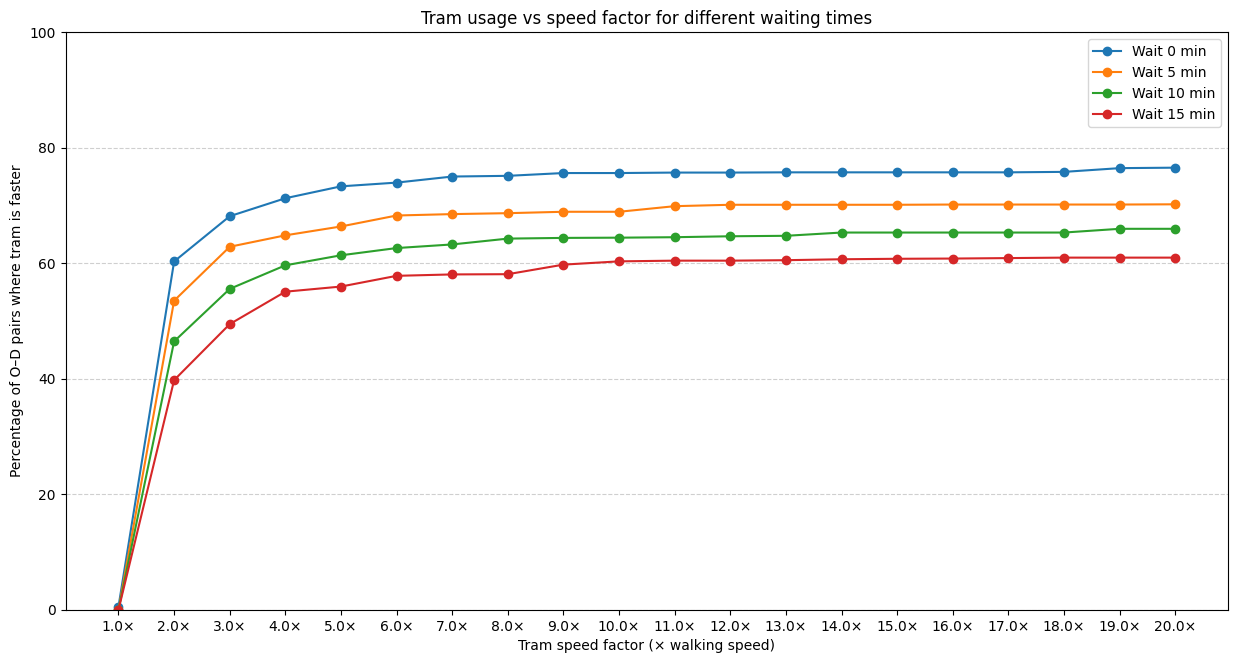

In [65]:
plt.figure(figsize=(15, 7.5))

x_labels = [f"{f:.1f}×" for f in tram_speed_factors]
x = range(len(tram_speed_factors))

for wait_min in waiting_times_min:
    plt.plot(x, results[wait_min], marker='o', label=f"Wait {wait_min} min")

plt.xticks(x, x_labels)
plt.ylim(0, 100)
plt.xlabel("Tram speed factor (× walking speed)")
plt.ylabel("Percentage of O–D pairs where tram is faster")
plt.title("Tram usage vs speed factor for different waiting times")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

plt.show()